# Week 8 — Retrieval Augmented Generation (RAG)
### *Grounded generation: getting models to **use evidence** instead of making things up.*

<a href="https://colab.research.google.com/github/tulane-intro-ai-engineering/main/blob/main/lectures/week8_rag.ipynb" target="_blank"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a>

---

## Learning objectives (by the end of this notebook, you can…)
- **Draw and explain** a full RAG pipeline (query → retrieval → context building → generation → citations).
- **Design chunking + retrieval settings** (chunk size, overlap, top-*k*) and predict how they affect quality and cost.
- **Reason about context limits** as an engineering constraint and implement a simple “context packer.”
- **Frame evaluation** for RAG using retrieval metrics (e.g., **Recall@k**) and generation metrics (e.g., **hallucination rate**).
- **Diagnose failures** (missed retrieval vs wrong retrieval vs ungrounded generation) and propose targeted fixes.
- **Make tradeoffs** among accuracy, groundedness, latency, and token cost for different application goals.

> **Assumption:** you already understand text embeddings and cosine similarity.  
> We’ll focus on *system design + evaluation*, and we’ll build a small RAG simulator to explore the engineering knobs.


In [1]:
# @title 🔧 Setup (Run this first)
!git clone --depth 1 -q https://github.com/tulane-intro-ai-engineering/main.git
import sys, numpy as np, matplotlib.pyplot as plt
sys.path.append('/content/main')
from course_utils import lab5_setup, show_mermaid
lab5_setup()
print('✅ Environment ready!')

Enter your OpenAI API key. It will only live in this Colab runtime.
OpenAI API key: ··········
✅ API key set.
✅ Environment ready!


---

# Day 1 (50 min) — RAG as a **pipeline**: grounding, chunking, top-*k*, and context limits

## Before we start: a quick “last lab” connection
In the first ~10 minutes of class, we usually do a quick **Lab Review**:
- a few students show what they built,
- we compare surprising results,
- we connect the lab’s “knobs” to today’s new system diagram.

### Discussion prompt
> **What was one thing you changed in last week’s lab that improved results — and what did it cost you (time, complexity, latency, tokens)?**

Keep that question in mind. RAG is *basically* a set of knobs that trade off **quality vs cost** — but now the knobs live in a *system* (retriever + generator).

---

## **Why can AI do something amazing… and then fail in a ridiculous way?**
RAG exists because modern LLMs have a tension:

- ✅ They can write coherent, helpful answers.
- ❌ They can also produce **confident nonsense** (hallucinations), including fake citations.

### Motivating example (success)
Imagine you have an internal policy wiki. A user asks:

> “Can interns access the on-call rotation?”

A well-engineered RAG system can:
1) retrieve the *relevant policy section*  
2) show the user the *exact lines*  
3) answer with a citation

### Motivating example (failure)
A naive system might respond:

> “Yes, interns are required to join the on-call rotation after 30 days (Policy 12.7).”

…but **Policy 12.7 doesn’t exist**.

### Guiding questions
- **Where does “truth” come from** in a RAG system: the model’s weights, or the retrieved context?
- **If retrieval is perfect**, can the generator still hallucinate?
- **If generation is perfect**, can retrieval still fail the system?


## **What exactly is a RAG pipeline? Where does grounding happen?**
A useful mental model:

- **Retrieval** decides *what evidence* the model gets to see.
- **Generation** decides *how to use that evidence* to produce an answer.
- **Grounding** is the property that the answer’s claims are **supported by the evidence**.

In practice, grounding depends on **multiple points** in the pipeline:
- Did we retrieve the right stuff?
- Did we include it in the context window?
- Did the model actually use it (and not “freewheel”)?
- Do citations correctly point to evidence?

We’ll build a miniature RAG pipeline in Python — not to compete with real systems, but to make the **engineering tradeoffs visible**.


In [5]:
# @title Visual: A RAG pipeline diagram (Mermaid)
mermaid = r'''
flowchart LR
    U["User Question"] --> QP["Query Processing\nrewrite | expand | filters"]
    QP --> R["Retriever\nvector | hybrid search"]
    R --> C["Candidates\ntop-k chunks"]
    C --> RR["Reranker (optional)"]
    RR --> P["Context Builder\npack within limits"]
    P --> G["Generator (LLM)"]
    G --> O["Answer + citations"]
    O --> M["Monitoring & Eval\nrecall@k, hallucination rate"]
    M --> QP
'''
show_mermaid(mermaid)


### A pipeline mindset: “a chain of probabilities”
Even if each component is *pretty good*, errors compound.

If:
- retrieval succeeds with probability 0.85
- context packing succeeds with probability 0.90
- generation stays grounded with probability 0.90

Then “end-to-end grounded answer” might be roughly:
$$
0.85 \times 0.90 \times 0.90 \approx 0.689
$$

That’s not a formal guarantee — just intuition: **pipelines amplify weaknesses**.

---

## **Let’s build a tiny RAG playground**
We’ll create:
1) a small “document collection”
2) a chunker
3) a toy embedding function (hashing trick)
4) cosine-similarity retrieval
5) context packing with a context limit

Then we’ll *stress test* it by changing chunk size, top-*k*, and context limits.


In [6]:
# @title Build a tiny corpus (policies + FAQs)
# We keep it small so we can *reason* about retrieval without needing external APIs.

corpus_docs = [
    {
        "doc_id": "policy_access",
        "title": "Access Control Policy",
        "text": '''
All employees must use single sign-on (SSO). Interns are granted access to internal tools
including Jira, Confluence, and GitHub Enterprise within the first week.

Interns may NOT access customer production data. Requests for elevated access require
manager approval and a security review. Access to incident response channels is read-only
unless the intern is explicitly added to an on-call rotation.
'''.strip(),
        "meta": {"type": "policy", "updated": "2025-09-01"}
    },
    {
        "doc_id": "policy_oncall",
        "title": "On-Call Rotation Policy",
        "text": '''
The on-call rotation is required for full-time engineers and optional for interns.
Interns may join on-call only after completing onboarding, passing the incident response
training quiz, and receiving manager approval. Interns should start with shadow shifts.

During on-call, responders must follow the runbook and document actions in the incident ticket.
'''.strip(),
        "meta": {"type": "policy", "updated": "2025-11-15"}
    },
    {
        "doc_id": "faq_security",
        "title": "Security FAQ",
        "text": '''
Q: Can interns access production?
A: No. Interns do not get production access unless the security team grants an exception.

Q: What is required for elevated access?
A: Manager approval, least-privilege review, and time-bounded access.
'''.strip(),
        "meta": {"type": "faq", "updated": "2024-06-20"}
    },
    {
        "doc_id": "runbook_incidents",
        "title": "Incident Response Runbook",
        "text": '''
Incident responders should: (1) acknowledge the page, (2) assess severity, (3) mitigate,
(4) communicate updates in the incident channel every 15 minutes, and (5) write a postmortem.

Shadow shifts are recommended for first-time responders. Keep notes of actions taken.
'''.strip(),
        "meta": {"type": "runbook", "updated": "2025-05-02"}
    }
]

print(f"Loaded {len(corpus_docs)} documents.")
for d in corpus_docs:
    print("-", d["doc_id"], "|", d["title"], "| updated:", d["meta"]["updated"])


Loaded 4 documents.
- policy_access | Access Control Policy | updated: 2025-09-01
- policy_oncall | On-Call Rotation Policy | updated: 2025-11-15
- faq_security | Security FAQ | updated: 2024-06-20
- runbook_incidents | Incident Response Runbook | updated: 2025-05-02


---

## **How should we chunk documents for retrieval?**
Chunking is one of the most important (and least glamorous) design choices in RAG.

### Why chunk at all?
Because:
- retrieval works over units (docs / passages / chunks),
- your context window is limited,
- and embedding similarity is “blurry” — it’s easier to match *short* relevant text than a whole book.

### The chunking tradeoff
- **Too small** → you lose local context (definitions, qualifiers), and you get lots of near-duplicate tiny matches.
- **Too large** → retrieval gets less precise; you waste context window tokens.

### A practical engineering view
Chunking is a **representation decision**. It controls what the retriever is even *allowed* to return.

We’ll use a simple word-based chunker here (real systems often use tokens and structure-aware splitting).


In [7]:
# @title Chunking utilities (chunk size + overlap)
import re

def tokenize_words(text: str):
    # simple word tokenizer
    return re.findall(r"[A-Za-z0-9']+", text.lower())

def detokenize_words(words):
    return " ".join(words)

def chunk_text_words(text: str, chunk_size: int = 80, overlap: int = 20):
    """Return list of chunks (strings). Word-based for clarity."""
    words = tokenize_words(text)
    if chunk_size <= 0:
        raise ValueError("chunk_size must be > 0")
    if overlap < 0 or overlap >= chunk_size:
        raise ValueError("overlap must satisfy 0 <= overlap < chunk_size")

    chunks = []
    start = 0
    while start < len(words):
        end = min(start + chunk_size, len(words))
        chunk = detokenize_words(words[start:end])
        chunks.append(chunk)
        if end == len(words):
            break
        start = end - overlap
    return chunks

def build_chunks(docs, chunk_size=80, overlap=20):
    chunks = []
    for d in docs:
        for i, ch in enumerate(chunk_text_words(d["text"], chunk_size=chunk_size, overlap=overlap)):
            chunks.append({
                "chunk_id": f'{d["doc_id"]}::chunk{i}',
                "doc_id": d["doc_id"],
                "title": d["title"],
                "text": ch,
                "meta": d["meta"]
            })
    return chunks

# Demo: make chunks and inspect
chunks_demo = build_chunks(corpus_docs, chunk_size=60, overlap=15)
print(f"Total chunks: {len(chunks_demo)}")
print("Example chunk ids:", [c['chunk_id'] for c in chunks_demo[:4]])
print("\nSample chunk text:\n", chunks_demo[0]["text"][:220], "…")


Total chunks: 5
Example chunk ids: ['policy_access::chunk0', 'policy_access::chunk1', 'policy_oncall::chunk0', 'faq_security::chunk0']

Sample chunk text:
 all employees must use single sign on sso interns are granted access to internal tools including jira confluence and github enterprise within the first week interns may not access customer production data requests for el …


### Reflection
> **What do you think happens to retrieval if we set `chunk_size=20` and `overlap=0`?**  
> What kinds of questions become harder to answer?

---

## **How do we retrieve chunks without a big embedding model?**
In real RAG, you’ll embed each chunk using an embedding model and store vectors in a vector DB.

Here, we’ll simulate embeddings with a **hashing trick**:
- map each word → an index in a fixed-size vector
- count occurrences
- L2-normalize
- cosine similarity

This keeps everything lightweight and still shows the core retrieval behaviors.


In [8]:
# @title Toy embedding + cosine retrieval (hashing trick)
def hashed_bow_embedding(text: str, dim: int = 256):
    words = tokenize_words(text)
    v = np.zeros(dim, dtype=np.float32)
    for w in words:
        idx = hash(w) % dim
        v[idx] += 1.0
    # L2 normalize
    norm = np.linalg.norm(v) + 1e-12
    return v / norm

def cosine_sim_matrix(query_vec, mat):
    # mat shape: (n, dim)
    return mat @ query_vec

class TinyVectorIndex:
    def __init__(self, chunks, dim=256):
        self.chunks = chunks
        self.dim = dim
        self.emb = np.stack([hashed_bow_embedding(c["text"], dim=dim) for c in chunks], axis=0)

    def search(self, query: str, top_k: int = 5):
        qv = hashed_bow_embedding(query, dim=self.dim)
        sims = cosine_sim_matrix(qv, self.emb)
        idxs = np.argsort(-sims)[:top_k]
        results = []
        for i in idxs:
            results.append((float(sims[i]), self.chunks[int(i)]))
        return results

# Build an index
chunks = build_chunks(corpus_docs, chunk_size=60, overlap=15)
index = TinyVectorIndex(chunks, dim=256)

# Try a query
query = "Can interns join the on-call rotation?"
results = index.search(query, top_k=5)

for score, ch in results:
    print(f"{score:0.3f} | {ch['chunk_id']} | {ch['title']}")


0.577 | policy_oncall::chunk0 | On-Call Rotation Policy
0.454 | policy_access::chunk0 | Access Control Policy
0.387 | faq_security::chunk0 | Security FAQ
0.347 | policy_access::chunk1 | Access Control Policy
0.157 | runbook_incidents::chunk0 | Incident Response Runbook


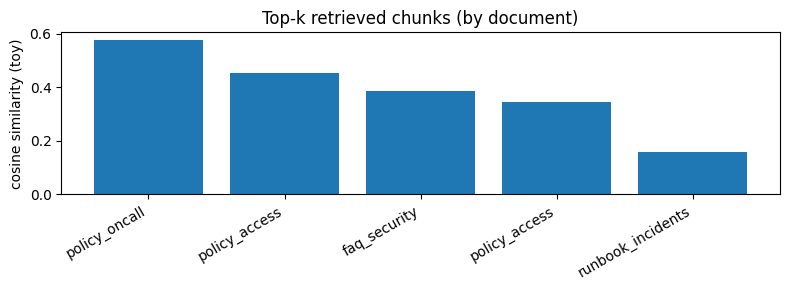

Tip: If the top results come from the wrong document, ask: is it chunking, embedding, or query wording?


In [9]:
# @title Visualize top-k similarity scores
query = "Can interns join the on-call rotation?"
results = index.search(query, top_k=8)

scores = [s for s, _ in results]
labels = [c["chunk_id"].split("::")[0] for _, c in results]

plt.figure(figsize=(8, 3))
plt.bar(range(len(scores)), scores)
plt.xticks(range(len(scores)), labels, rotation=30, ha="right")
plt.ylabel("cosine similarity (toy)")
plt.title("Top-k retrieved chunks (by document)")
plt.tight_layout()
plt.show()

print("Tip: If the top results come from the wrong document, ask: is it chunking, embedding, or query wording?")


### Reflection
> If two different documents are both “about interns,” how might the retriever confuse them?  
> What metadata filters (date, doc type, department) could help?

---

## **What does “top-*k*” really mean?**
When we set `top_k=5`, we’re asking:  
> “Give me the 5 chunks that look most similar to my query embedding.”

But **RAG doesn’t end at retrieval**. The generator only sees what fits into its context window.

That leads to the next question:

---

## **How do context limits change everything?**
Even with a huge context window, you still pay:
- money (tokens)
- latency
- attention dilution (too much text → model ignores key lines)

So we need a **context builder**: select, order, and pack chunks.

We’ll implement a simple context packer using a word budget as a proxy for tokens.


In [10]:
# @title Context builder: pack top results under a budget
def approx_token_count(text: str) -> int:
    # crude proxy: 1 token ~ 0.75 words (varies by tokenizer)
    words = len(tokenize_words(text))
    return int(words / 0.75) + 1

def build_context(retrieved_chunks, max_tokens: int = 220, include_metadata=True):
    context_parts = []
    used = 0

    for score, ch in retrieved_chunks:
        header = f"[source={ch['chunk_id']} title={ch['title']} updated={ch['meta']['updated']}]\n"
        body = ch["text"].strip() + "\n"
        block = (header + body) if include_metadata else body

        t = approx_token_count(block)
        if used + t > max_tokens:
            break
        context_parts.append(block)
        used += t

    return "\n".join(context_parts), used

query = "Can interns join the on-call rotation?"
retrieved = index.search(query, top_k=8)
context, used_tokens = build_context(retrieved, max_tokens=200)

print(f"Approx tokens used: {used_tokens}\n")
print(context[:900], "…")


Approx tokens used: 187

[source=policy_oncall::chunk0 title=On-Call Rotation Policy updated=2025-11-15]
the on call rotation is required for full time engineers and optional for interns interns may join on call only after completing onboarding passing the incident response training quiz and receiving manager approval interns should start with shadow shifts during on call responders must follow the runbook and document actions in the incident ticket

[source=policy_access::chunk0 title=Access Control Policy updated=2025-09-01]
all employees must use single sign on sso interns are granted access to internal tools including jira confluence and github enterprise within the first week interns may not access customer production data requests for elevated access require manager approval and a security review access to incident response channels is read only unless the intern is explicitly added to an on
 …


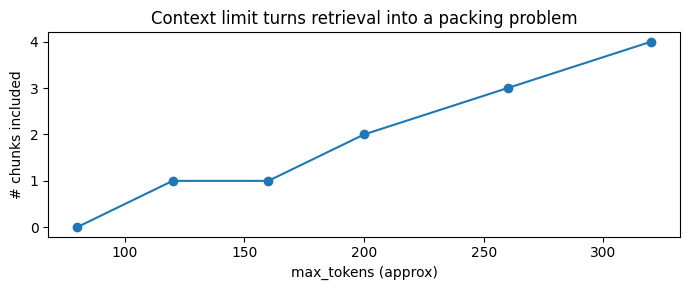

Discussion: retrieval might return 12 chunks, but the model might only see the first 3–6.


In [11]:
# @title Visual: context budget vs number of included chunks
query = "Can interns join the on-call rotation?"
retrieved = index.search(query, top_k=12)

budgets = [80, 120, 160, 200, 260, 320]
included = []
used_list = []

for b in budgets:
    ctx, used = build_context(retrieved, max_tokens=b)
    used_list.append(used)
    # Count how many sources made it in (roughly: each chunk has a header line)
    n_sources = ctx.count("[source=")
    included.append(n_sources)

plt.figure(figsize=(7,3))
plt.plot(budgets, included, marker="o")
plt.xlabel("max_tokens (approx)")
plt.ylabel("# chunks included")
plt.title("Context limit turns retrieval into a packing problem")
plt.tight_layout()
plt.show()

print("Discussion: retrieval might return 12 chunks, but the model might only see the first 3–6.")


### Reflection
> Suppose you increase `top_k` from 5 to 20.  
> **What do you expect to happen** if the context budget stays fixed?

---

## **Mini-activity (pair & share): design a better context builder**
With a partner, sketch improvements to `build_context()`:

1) **Diversity:** avoid including 6 chunks from the same doc if 1–2 are enough  
2) **Recency:** prefer newer policy versions  
3) **Reranking:** move the most useful chunk to the top  
4) **Compression:** summarize long chunks (but watch out: summarization can hallucinate too!)

> **Key idea:** In RAG, “retrieval quality” is not the same as “what the model actually sees.”

---

# Day 1 Wrap-up
- RAG is a **pipeline**, not a single model call.
- Chunking defines the retriever’s “units of thought.”
- Top-*k* is the retriever’s candidate list — not the final context.
- Context limits force a **packing problem**, which creates its own failure modes.

Next: we’ll learn how to **evaluate** RAG systems and make tradeoffs.


---

# Day 2 (50 min) — Evaluating RAG: recall@k, hallucination rate, and tradeoffs

## **How do we know if our RAG system is “good”?**
A tricky fact:

> A RAG system can look good in demos and still fail in production, because failures are rare but high-impact.

So we need evaluation that answers:
1) **Did we retrieve the right evidence?**  
2) **Did we include it in the model’s context?**  
3) **Did the model’s answer stay grounded in that evidence?**

We’ll formalize these with:
- **Recall@k** (retrieval)
- **Within-context recall** (retrieval + packing)
- **Hallucination rate** (generation groundedness)

---

## **Step 1: Build an evaluation set**
In production, you’d curate:
- representative user questions,
- a ground-truth answer (or rubric),
- and (often) “gold” supporting passages.

Here, we’ll label gold documents/chunks by hand for a small set of queries.


In [13]:
# @title Build a tiny labeled dataset (queries + gold docs)
eval_queries = [
    {
        "q": "Can interns join the on-call rotation?",
        "gold_doc_ids": {"policy_oncall"},
    },
    {
        "q": "Do interns get production access?",
        "gold_doc_ids": {"faq_security", "policy_access"},
    },
    {
        "q": "What are incident responders supposed to do during an incident?",
        "gold_doc_ids": {"runbook_incidents"},
    },
    {
        "q": "What is required for elevated access?",
        "gold_doc_ids": {"faq_security", "policy_access"},
    },
]

for ex in eval_queries:
    print("-", ex["q"], " | gold:", ex["gold_doc_ids"])


- Can interns join the on-call rotation?  | gold: {'policy_oncall'}
- Do interns get production access?  | gold: {'faq_security', 'policy_access'}
- What are incident responders supposed to do during an incident?  | gold: {'runbook_incidents'}
- What is required for elevated access?  | gold: {'faq_security', 'policy_access'}


## **What is Recall@k?**
Recall@k measures:

> “For what fraction of queries did the retriever return at least one relevant item in the top-*k* results?”

Formally, for a set of queries \(Q\):
$$
\text{Recall@k} = \frac{1}{|Q|}\sum_{q \in Q} \mathbf{1}\{\text{gold}(q)\cap \text{top}_k(q)\neq \emptyset\}
$$

**Interpretation:**
- Recall@1: “Did the very top result contain relevant evidence?”
- Recall@5: “Did we at least retrieve something relevant among the first 5?”

**Important:** Recall@k is a *retrieval* metric — it does not measure grounded generation.

Let’s compute it.


In [14]:
# @title Compute Recall@k for our toy index
def recall_at_k(index, eval_queries, k=5):
    hits = 0
    for ex in eval_queries:
        retrieved = index.search(ex["q"], top_k=k)
        retrieved_docs = {ch["doc_id"] for _, ch in retrieved}
        if len(retrieved_docs & ex["gold_doc_ids"]) > 0:
            hits += 1
    return hits / len(eval_queries)

for k in [1, 2, 3, 5, 8, 10]:
    r = recall_at_k(index, eval_queries, k=k)
    print(f"Recall@{k}: {r:0.2f}")


Recall@1: 1.00
Recall@2: 1.00
Recall@3: 1.00
Recall@5: 1.00
Recall@8: 1.00
Recall@10: 1.00


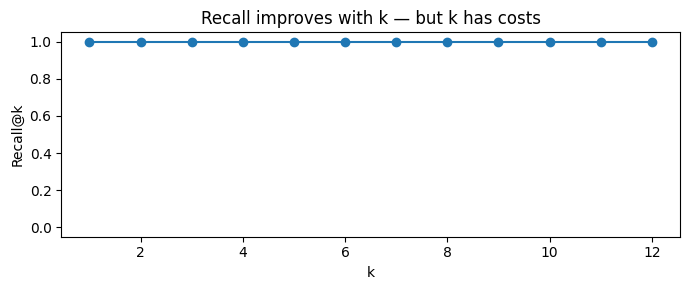

Think: If k increases, cost/latency increases — and context packing may still hide evidence.


In [15]:
# @title Visualize Recall@k as a curve
ks = list(range(1, 13))
recalls = [recall_at_k(index, eval_queries, k=k) for k in ks]

plt.figure(figsize=(7,3))
plt.plot(ks, recalls, marker="o")
plt.ylim(-0.05, 1.05)
plt.xlabel("k")
plt.ylabel("Recall@k")
plt.title("Recall improves with k — but k has costs")
plt.tight_layout()
plt.show()

print("Think: If k increases, cost/latency increases — and context packing may still hide evidence.")


### Reflection
> If Recall@k looks great, does that guarantee good user answers?  
> Why or why not?

---

## **Recall@k isn’t enough: the context window bottleneck**
Your retriever might return relevant evidence at rank 9… but if your context builder only fits 4 chunks, the model never sees it.

So we define an additional metric:

### Within-context recall
> “For what fraction of queries does the packed context include at least one gold item?”

This captures retrieval + packing together.


In [16]:
# @title Compute within-context recall under a token budget
def within_context_recall(index, eval_queries, top_k=10, max_tokens=200):
    hits = 0
    for ex in eval_queries:
        retrieved = index.search(ex["q"], top_k=top_k)
        ctx, _ = build_context(retrieved, max_tokens=max_tokens)
        # Did we include a gold doc?
        included_docs = set()
        for line in ctx.splitlines():
            if line.startswith("[source="):
                # parse doc_id from chunk_id
                chunk_id = line.split("source=")[1].split()[0].strip("]")
                doc_id = chunk_id.split("::")[0]
                included_docs.add(doc_id)
        if len(included_docs & ex["gold_doc_ids"]) > 0:
            hits += 1
    return hits / len(eval_queries)

for budget in [80, 120, 160, 200, 260, 320]:
    r = within_context_recall(index, eval_queries, top_k=12, max_tokens=budget)
    print(f"Within-context recall (top_k=12, max_tokens={budget}): {r:0.2f}")


Within-context recall (top_k=12, max_tokens=80): 0.75
Within-context recall (top_k=12, max_tokens=120): 1.00
Within-context recall (top_k=12, max_tokens=160): 1.00
Within-context recall (top_k=12, max_tokens=200): 1.00
Within-context recall (top_k=12, max_tokens=260): 1.00
Within-context recall (top_k=12, max_tokens=320): 1.00


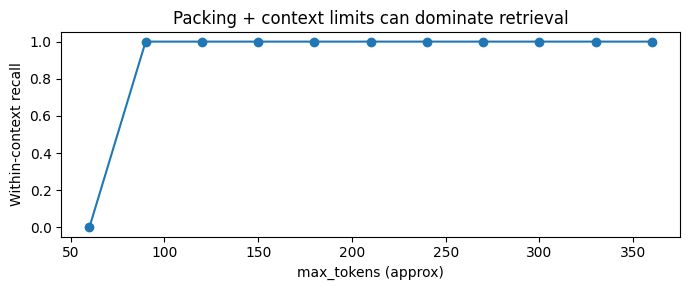

In [17]:
# @title Visualize within-context recall vs context budget
budgets = list(range(60, 361, 30))
wcr = [within_context_recall(index, eval_queries, top_k=12, max_tokens=b) for b in budgets]

plt.figure(figsize=(7,3))
plt.plot(budgets, wcr, marker="o")
plt.ylim(-0.05, 1.05)
plt.xlabel("max_tokens (approx)")
plt.ylabel("Within-context recall")
plt.title("Packing + context limits can dominate retrieval")
plt.tight_layout()
plt.show()


### Reflection
> Can you think of a system where **Recall@20 is high** but **within-context recall is low**?  
> What might cause that (chunk size, duplicates, irrelevant chunks, ordering)?

---

## **Step 2: Measuring hallucination rate (groundedness)**
Now we focus on the generator side.

A practical definition:

1) Split the answer into **atomic claims** (we’ll approximate with sentences).
2) For each claim, check whether it is supported by the retrieved context.
3) Hallucination rate is:
$$
\text{Hallucination Rate} = \frac{\#\text{unsupported claims}}{\#\text{total claims}}
$$

In real systems, “supported” is judged by:
- human annotators with a rubric, or
- an LLM-as-judge (plus auditing).

We’ll build a *toy checker* using string overlap to illustrate the concept.


In [19]:
# @title A toy "generator" and a toy "grounding checker"
import random
def rag_answer_toy(query: str, context: str, p_hallucinate: float = 0.25):
    """A deliberately simple generator:
    - If context contains keywords, produce an evidence-based sentence.
    - Sometimes add an ungrounded (hallucinated) sentence.
    """
    q = query.lower()
    ctx = context.lower()

    sentences = []

    if "on-call" in q and "intern" in q:
        if "optional for interns" in ctx or "interns may join" in ctx:
            sentences.append("Interns may join the on-call rotation after onboarding and manager approval.")
        else:
            sentences.append("I could not find a policy statement about interns and on-call in the provided sources.")

    elif "production" in q and "intern" in q:
        if "do not get production access" in ctx or "may not access customer production data" in ctx:
            sentences.append("Interns do not have production access unless an exception is granted.")
        else:
            sentences.append("I could not find an explicit statement about intern production access in the provided sources.")

    elif "incident" in q and ("responders" in q or "during an incident" in q):
        if "acknowledge" in ctx and "postmortem" in ctx:
            sentences.append("Responders should acknowledge the page, mitigate, communicate updates, and write a postmortem.")
        else:
            sentences.append("I could not find the incident response steps in the provided sources.")

    elif "elevated access" in q:
        if "manager approval" in ctx and ("least-privilege" in ctx or "least privilege" in ctx):
            sentences.append("Elevated access requires manager approval and a least-privilege review.")
        else:
            sentences.append("I could not find the elevated access requirements in the provided sources.")

    else:
        sentences.append("I am not sure; the provided sources do not clearly answer this question.")

    # Add citations-like markers (toy)
    if "[source=" in context:
        # cite the first source we see
        first_source = None
        for line in context.splitlines():
            if line.startswith("[source="):
                first_source = line.split("source=")[1].split()[0].strip("]")
                break
        if first_source:
            sentences[-1] += f" (see {first_source})"

    # Optional hallucination: add a confident but unsupported claim
    if random.random() < p_hallucinate:
        sentences.append("Interns are required to join on-call after 30 days. (Policy 12.7)")

    return " ".join(sentences)

def split_into_claims(text: str):
    # simple sentence split
    parts = re.split(r"(?<=[.!?])\s+", text.strip())
    return [p.strip() for p in parts if p.strip()]

def claim_supported_by_context(claim: str, context: str, min_overlap_words: int = 4):
    """Toy support check:
    claim is 'supported' if it shares enough content words with context.
    This is NOT a real grounding evaluator — it's a teaching tool.
    """
    claim_words = set([w for w in tokenize_words(claim) if len(w) >= 4])
    ctx_words = set([w for w in tokenize_words(context) if len(w) >= 4])
    overlap = len(claim_words & ctx_words)
    return overlap >= min_overlap_words, overlap

def hallucination_rate(answer: str, context: str):
    claims = split_into_claims(answer)
    if not claims:
        return 0.0, []
    unsupported = 0
    details = []
    for c in claims:
        ok, overlap = claim_supported_by_context(c, context)
        details.append({"claim": c, "supported": ok, "overlap": overlap})
        unsupported += (0 if ok else 1)
    return unsupported / len(claims), details

# Demo on one query
q = "Can interns join the on-call rotation?"
retrieved = index.search(q, top_k=8)
ctx, _ = build_context(retrieved, max_tokens=180)

ans = rag_answer_toy(q, ctx, p_hallucinate=0.5)
hr, details = hallucination_rate(ans, ctx)

print("QUESTION:", q)
print("\nANSWER:", ans)
print(f"\nHallucination rate (toy): {hr:0.2f}")
print("\nPer-claim analysis:")
for d in details:
    flag = "✅" if d["supported"] else "❌"
    print(f"{flag} overlap={d['overlap']:2d} | {d['claim']}")


QUESTION: Can interns join the on-call rotation?

ANSWER: Interns may join the on-call rotation after onboarding and manager approval. (see policy_oncall::chunk0)

Hallucination rate (toy): 0.50

Per-claim analysis:
✅ overlap= 8 | Interns may join the on-call rotation after onboarding and manager approval.
❌ overlap= 3 | (see policy_oncall::chunk0)


### Why this toy checker is still useful
Our “overlap” judge is crude, but it illustrates the core product question:

> **Are we measuring *truth* or *groundedness*?**

- An answer can be **true but ungrounded** (model knew it from training).
- An answer can be **grounded but incomplete** (retrieved evidence is partial).
- An answer can be **fluent but wrong** (classic hallucination).

In many real deployments, *groundedness* matters more than “sounding smart.”

---

## **End-to-end evaluation: combine retrieval and grounding**
Let’s define an end-to-end metric:

> A query is a “success” if:
> 1) within-context recall hits (gold evidence is present), **and**
> 2) hallucination rate is below a threshold (e.g., ≤ 0.25).

This is simplistic — but it mirrors how teams set **acceptance tests** for RAG features.


In [20]:
# @title End-to-end evaluation: retrieval + grounded generation (toy)
def evaluate_end_to_end(index, eval_queries, top_k=10, max_tokens=200, p_hallucinate=0.25, hr_thresh=0.25):
    results = []
    for ex in eval_queries:
        retrieved = index.search(ex["q"], top_k=top_k)
        ctx, _ = build_context(retrieved, max_tokens=max_tokens)
        ans = rag_answer_toy(ex["q"], ctx, p_hallucinate=p_hallucinate)

        # within-context recall for this example
        included_docs = set()
        for line in ctx.splitlines():
            if line.startswith("[source="):
                chunk_id = line.split("source=")[1].split()[0].strip("]")
                included_docs.add(chunk_id.split("::")[0])
        wcr_hit = len(included_docs & ex["gold_doc_ids"]) > 0

        hr, _ = hallucination_rate(ans, ctx)
        ok = wcr_hit and (hr <= hr_thresh)
        results.append({"q": ex["q"], "wcr_hit": wcr_hit, "hr": hr, "ok": ok})
    return results

res = evaluate_end_to_end(index, eval_queries, top_k=12, max_tokens=180, p_hallucinate=0.35, hr_thresh=0.25)
for r in res:
    print(("✅" if r["ok"] else "❌"), f"wcr={r['wcr_hit']} hr={r['hr']:.2f} | {r['q']}")

success_rate = sum(r["ok"] for r in res) / len(res)
print("\nToy end-to-end success rate:", round(success_rate, 2))


❌ wcr=True hr=0.33 | Can interns join the on-call rotation?
❌ wcr=True hr=0.33 | Do interns get production access?
❌ wcr=True hr=0.33 | What are incident responders supposed to do during an incident?
❌ wcr=True hr=0.50 | What is required for elevated access?

Toy end-to-end success rate: 0.0


### Reflection
> If success is low, what should we fix first: retrieval, packing, or generation?  
> How would you *tell* which one is the bottleneck?

---

## **Tradeoffs: the RAG “knob dashboard”**
When teams tune RAG, they often adjust:

- **Chunk size / overlap**
- **Retriever top-*k***
- **Context budget**
- **Reranking**
- **Query rewriting**
- **Metadata filters** (recency, product, team, permissions)

We’ll explore a few tradeoffs quantitatively by sweeping parameters and plotting metrics.

Remember: *your goal is not to maximize one metric.*  
Your goal is to choose a configuration that fits product constraints.


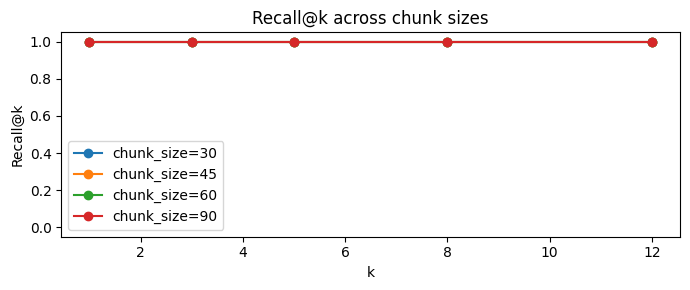

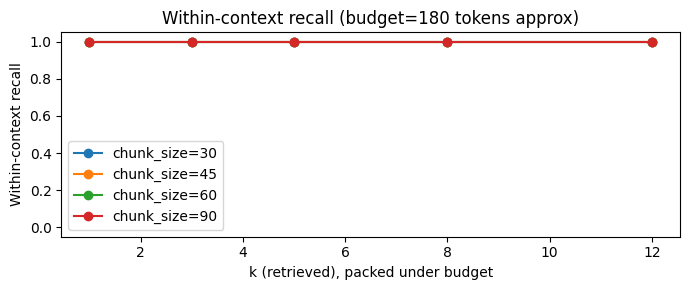

Interpretation idea: larger chunks may help context, but they also consume budget faster.


In [21]:
# @title Sweep chunk size and top-k, visualize Recall@k and within-context recall
def build_index_for_settings(chunk_size, overlap, dim=256):
    ch = build_chunks(corpus_docs, chunk_size=chunk_size, overlap=overlap)
    return TinyVectorIndex(ch, dim=dim)

chunk_sizes = [30, 45, 60, 90]
topks = [1, 3, 5, 8, 12]
budget = 180

grid_recall = np.zeros((len(chunk_sizes), len(topks)))
grid_wcr = np.zeros_like(grid_recall)

for i, cs in enumerate(chunk_sizes):
    idx = build_index_for_settings(cs, overlap=max(0, cs//4))
    for j, k in enumerate(topks):
        grid_recall[i, j] = recall_at_k(idx, eval_queries, k=k)
        grid_wcr[i, j] = within_context_recall(idx, eval_queries, top_k=max(k, 12), max_tokens=budget)

# Plot as lines: each chunk size is one line
plt.figure(figsize=(7,3))
for i, cs in enumerate(chunk_sizes):
    plt.plot(topks, grid_recall[i], marker="o", label=f"chunk_size={cs}")
plt.ylim(-0.05, 1.05)
plt.xlabel("k")
plt.ylabel("Recall@k")
plt.title("Recall@k across chunk sizes")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,3))
for i, cs in enumerate(chunk_sizes):
    plt.plot(topks, grid_wcr[i], marker="o", label=f"chunk_size={cs}")
plt.ylim(-0.05, 1.05)
plt.xlabel("k (retrieved), packed under budget")
plt.ylabel("Within-context recall")
plt.title(f"Within-context recall (budget={budget} tokens approx)")
plt.legend()
plt.tight_layout()
plt.show()

print("Interpretation idea: larger chunks may help context, but they also consume budget faster.")


### Reflection
> Look at the two curves.  
> **When does increasing `k` stop helping within-context recall?**  
> Why might that happen?

---

## **A common real-world failure: “high recall, low usefulness”**
You can retrieve relevant evidence but still fail because:
- the relevant chunk is **buried** among similar but less useful chunks,
- the context is **too long** and the generator ignores key lines,
- or the generator produces an answer that isn’t supported.

This is why many production RAG systems add a **reranker**.

We won’t implement a full cross-encoder reranker here, but we can simulate reranking by:
- preferring chunks from *gold docs* (as if the reranker “understood” better),
- or by adding a simple heuristic: boost chunks that contain query keywords.


In [22]:
# @title Simple heuristic reranker: boost keyword overlap
def keyword_overlap_score(query: str, chunk_text: str):
    q_words = set([w for w in tokenize_words(query) if len(w) >= 4])
    c_words = set([w for w in tokenize_words(chunk_text) if len(w) >= 4])
    return len(q_words & c_words)

def rerank_results(query: str, retrieved_results, alpha: float = 0.7):
    """Combine cosine similarity (already in retrieved_results) with keyword overlap."""
    scores = []
    for sim, ch in retrieved_results:
        kw = keyword_overlap_score(query, ch["text"])
        combined = alpha * sim + (1 - alpha) * (kw / 10.0)  # scale kw roughly
        scores.append((combined, sim, kw, ch))
    scores.sort(key=lambda x: -x[0])
    return scores

q = "What is required for elevated access?"
retrieved = index.search(q, top_k=10)
reranked = rerank_results(q, retrieved, alpha=0.6)

print("Top 5 BEFORE rerank:")
for sim, ch in retrieved[:5]:
    print(f"{sim:0.3f} | {ch['chunk_id']} | {ch['title']}")

print("\nTop 5 AFTER rerank:")
for comb, sim, kw, ch in reranked[:5]:
    print(f"comb={comb:0.3f} sim={sim:0.3f} kw={kw:2d} | {ch['chunk_id']} | {ch['title']}")


Top 5 BEFORE rerank:
0.470 | faq_security::chunk0 | Security FAQ
0.367 | policy_access::chunk0 | Access Control Policy
0.281 | policy_access::chunk1 | Access Control Policy
0.195 | policy_oncall::chunk0 | On-Call Rotation Policy
0.113 | runbook_incidents::chunk0 | Incident Response Runbook

Top 5 AFTER rerank:
comb=0.442 sim=0.470 kw= 4 | faq_security::chunk0 | Security FAQ
comb=0.300 sim=0.367 kw= 2 | policy_access::chunk0 | Access Control Policy
comb=0.169 sim=0.281 kw= 0 | policy_access::chunk1 | Access Control Policy
comb=0.157 sim=0.195 kw= 1 | policy_oncall::chunk0 | On-Call Rotation Policy
comb=0.068 sim=0.113 kw= 0 | runbook_incidents::chunk0 | Incident Response Runbook


In [23]:
# @title Compare within-context recall with vs without rerank (toy heuristic)
def within_context_recall_with_rerank(index, eval_queries, top_k=12, max_tokens=180, alpha=0.6):
    hits = 0
    for ex in eval_queries:
        retrieved = index.search(ex["q"], top_k=top_k)
        reranked = rerank_results(ex["q"], retrieved, alpha=alpha)
        # keep only (score, chunk) for packing, using combined score order
        reranked_for_pack = [(comb, ch) for (comb, sim, kw, ch) in reranked]
        ctx, _ = build_context(reranked_for_pack, max_tokens=max_tokens)

        included_docs = set()
        for line in ctx.splitlines():
            if line.startswith("[source="):
                chunk_id = line.split("source=")[1].split()[0].strip("]")
                included_docs.add(chunk_id.split("::")[0])

        if len(included_docs & ex["gold_doc_ids"]) > 0:
            hits += 1
    return hits / len(eval_queries)

base = within_context_recall(index, eval_queries, top_k=12, max_tokens=180)
rer = within_context_recall_with_rerank(index, eval_queries, top_k=12, max_tokens=180, alpha=0.6)

print("Within-context recall (no rerank):", round(base, 2))
print("Within-context recall (heuristic rerank):", round(rer, 2))


Within-context recall (no rerank): 1.0
Within-context recall (heuristic rerank): 1.0


### Reflection
> Why might reranking improve within-context recall even if Recall@k stays the same?

---

## **Putting it together: a practical RAG evaluation checklist**
When you evaluate a RAG system, try to log (and break down) metrics like:

### Retrieval
- Recall@k (did we retrieve any relevant evidence?)
- MRR / rank of first relevant item
- Diversity (how many distinct docs are in the top-*k*?)
- Filtering correctness (permissions, recency, product, locale)

### Context building
- Within-context recall
- Average context length / token cost
- Duplicate rate
- Source coverage (are we over-relying on one doc?)

### Generation / grounding
- Hallucination rate (unsupported or contradicted claims)
- Citation precision (do citations actually support the claim?)
- “I don’t know” correctness (abstain when evidence is missing)

### End-to-end
- Task success (human rubric, or measurable outcomes)
- Latency and cost budgets

---

# In-class: Designing next week’s lab (work time)
Next week’s lab goal: **Implement and evaluate a small RAG system** with a real-ish dataset.

### Suggested lab structure
1) Load a corpus (e.g., course notes, FAQs, short Wikipedia pages, product docs)
2) Chunk documents with at least 2 strategies
3) Retrieve top-*k* with embeddings (you can use a real embedding model in the lab)
4) Build context under a fixed budget
5) Evaluate:
   - Recall@k (and within-context recall)
   - a groundedness proxy (citation checks / claim support)
6) Write a short reflection on tradeoffs you observed

### Lab work prompt (start now)
- Pick one knob to sweep: **chunk size**, **overlap**, or **k**
- Decide what you will log
- Sketch what plots you’ll include in your writeup

> **Pair & share:** Compare your lab plan with a partner. Where do you expect the biggest surprises?

---

# Week wrap-up
RAG is not a “feature” — it’s a **system**.  
If you want trustworthy outputs, you need:
- retrieval that finds evidence,
- context building that *preserves* evidence under limits,
- generation that stays grounded,
- and evaluation that tells you *which part failed*.


---

<details>
<summary><strong>Instructor Notes</strong> (click to expand)</summary>

### Suggested pacing (2 × 50 min)

#### Day 1 (50 min)
- **0–10 min** — Lab review  
  - Pick 2–3 students to share results.  
  - Ask: “What knob improved things, and what did it cost?”
- **10–18 min** — Motivation + the grounding problem  
  - Success story: “answer with citations”  
  - Failure story: “fake policy / fake citation”
- **18–28 min** — Pipeline diagram + grounding checkpoints  
  - Emphasize: retrieval ≠ grounding; packing matters.
- **28–40 min** — Chunking + top-k + context limits  
  - Show the packing plot.  
  - Key transition line: “Top-k is *not* what the model sees.”
- **40–48 min** — Pair activity: propose a better context builder  
  - Collect 3 ideas on the board: diversity, recency, reranking, compression.
- **48–50 min** — Wrap + preview evaluation

**Slide cues**
- Slide: “RAG is a pipeline” (diagram)
- Slide: “Three knobs triangle: chunking / k / context budget”
- Slide: “Failure modes” (missed retrieval, wrong retrieval, context dilution, attribution error)

#### Day 2 (50 min)
- **0–8 min** — Why evaluation is tricky  
  - Two failure cases:
    1) right evidence retrieved, model still hallucinates  
    2) wrong evidence retrieved, model answers “correctly” anyway
- **8–22 min** — Recall@k + within-context recall  
  - Use curve plots.  
  - Ask: “Where does k stop helping?”
- **22–35 min** — Hallucination rate framing  
  - Explain claims + support rubric.  
  - Stress: our toy checker is illustrative, not production-grade.
- **35–45 min** — Tradeoffs + reranking motivation  
  - Show rerank comparison.
- **45–50 min** — Introduce next lab and start planning  
  - Students select knobs and plots for their lab report.

### Discussion transitions
- After retrieval curves:  
  **“Now imagine the relevant chunk is ranked 9th. What happens when we only fit 4 chunks?”**
- Before hallucination:  
  **“Even with perfect evidence, can the model still make things up?”**
- Before tradeoffs:  
  **“Metrics are tools. Product goals decide which metric matters most.”**

### Optional extensions (advanced)
- Introduce **hybrid retrieval** (BM25 + embeddings) and discuss why embeddings alone miss rare keywords.
- Discuss **query rewriting** and “query drift.”
- Discuss **citation precision** vs **citation recall**.
- Introduce **calibration/abstention**: thresholding on retrieval confidence to say “I don’t know.”

### If students finish early
- Challenge: modify `build_context()` to enforce **diversity** (e.g., max 2 chunks per doc).
- Challenge: design a better groundedness check (e.g., entailment-style using an LLM in the lab).

</details>
